1. Implement univariate linear regression from scratch and evaluate the model. Use all the relevant concepts from the learning resource. Use data wrangling and EDA if required. Use Salary Data which can be downloaded from here. Split the data set into train and test sets [only for this you can use sklearn] . For implementation from scratch you can take ideas from here.

In [54]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
df=pd.read_csv('Salary_dataset.csv')
df.shape

(30, 3)

In [56]:
df

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [57]:
# delete the 'Unnamed: 0' column
df.drop(columns=['Unnamed: 0'], inplace=True)
# Display the first few rows of the DataFrame   
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [58]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [59]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


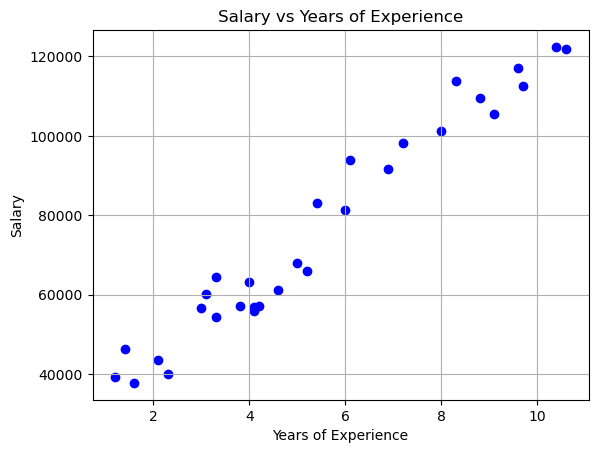

In [61]:
# EDA - Visualize the data
plt.scatter(df['YearsExperience'], df['Salary'], color='blue')
plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.grid(True)
plt.show()

In [62]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


In [63]:
class UnivariateLinearRegressor:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta = None # stores model parameters (intercept & slope).
        self.MSE_loss_history = [] # records loss after each iteration.
        self.theta_history = [] #records parameter values after each iteration.
        
    def MSE_loss(self, y_pred, y):
        m = y.shape[0]
        loss = (1 / (2 * m)) * np.sum((y_pred - y)**2) #1/2m is used to simplify the derivative in gradient descent.
        return loss
    

    # Computes partial derivatives of MSE loss w.r.t. theta[0] (bias) and theta[1] (slope).
    # updates theta[0] and theta[1] using the computed gradients.
    def gradient_descent(self, X, y, y_pred, theta):
        m = y.shape[0]
        # Compute gradients first
        gradient_0 = np.sum(y_pred - y) / m
        gradient_1 = np.sum(np.dot((y_pred - y).T, X[:, 1])) / m #

        # Update parameters
        theta[0] = theta[0] - self.learning_rate * gradient_0
        theta[1] = theta[1] - self.learning_rate * gradient_1
        
        return theta
    
    def fit(self, X: np.ndarray, y:np.ndarray) -> np.ndarray:
        """
        Reshape the input X and train the model

        Args:
            X (np.ndarray): Input feature matrix of dimension (n_samples, n_features)
            y (np.ndarray): Label matrix of dimension (n_samples, 1)

        Returns:
            np.ndarray: Parameter: theta matrix of dimension (n_features+1, 1)
        """
        # Add new dimension to X
        new_dimension = np.ones((X.shape[0], 1))
        X = np.hstack((new_dimension, X))

        # Initialize theta
        self.theta = np.zeros((X.shape[1], 1))
        
        # Training loop
        for i in range(self.n_iters):
            y_pred = np.dot(X, self.theta)
            # compute loss
            loss = self.MSE_loss(y_pred, y)
            self.MSE_loss_history.append(loss)
            self.theta_history.append(self.theta)
            
            
            if i % 100 == 0:
                print(f"Iteration {i}: MSE Loss = {loss}")
            
            # use gradient descent
            self.theta = self.gradient_descent(X, y, y_pred, self.theta)
        
        return self.theta
    
    def predict(self, X: np.ndarray, theta: np.ndarray) -> np.ndarray:
        # This function assumes that X has been normalized
        new_dimension = np.ones((X.shape[0], 1))
        X = np.hstack((new_dimension, X))
        predictions = np.dot(X, theta)
        
        return predictions

In [64]:
from sklearn.model_selection import train_test_split
# Extracting feature and target
X = df['YearsExperience'].values
y = df['Salary'].values

# Split into training and testing sets (Only using sklearn here)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
#reshaping X_train and X_test to be 2D arrays
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)
print(X_train.shape,y_train.shape)

(24, 1) (24,)


In [66]:
y_train = y_train.reshape(-1, 1)

In [67]:
y_train.shape

(24, 1)

In [68]:
# Mean Normalization and Feature scaling
X_train_mean = np.mean(X_train)
X_train_std = np.std(X_train)
X_train = (X_train - X_train_mean) / X_train_std

y_train_mean = np.mean(y_train)
y_train_std = np.std(y_train)
y_train = (y_train - y_train_mean) / y_train_std

In [69]:
myModel = UnivariateLinearRegressor(learning_rate=0.01, n_iters=1000)
theta = myModel.fit(X_train, y_train)

Iteration 0: MSE Loss = 0.5
Iteration 100: MSE Loss = 0.08234430966314454
Iteration 200: MSE Loss = 0.026386936069235006
Iteration 300: MSE Loss = 0.018889785349217498
Iteration 400: MSE Loss = 0.017885319533388414
Iteration 500: MSE Loss = 0.0177507415299777
Iteration 600: MSE Loss = 0.0177327108128377
Iteration 700: MSE Loss = 0.017730295063217823
Iteration 800: MSE Loss = 0.017729971401869216
Iteration 900: MSE Loss = 0.01772992803782697


In [80]:
myModel.theta

array([[2.58335020e-16],
       [9.82067655e-01]])

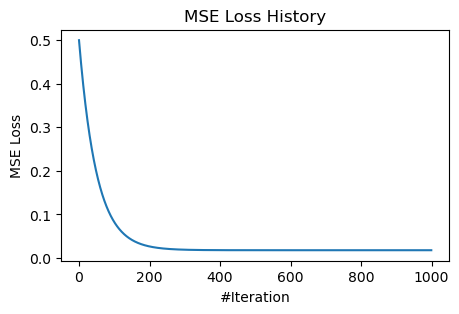

In [70]:
# Plotting Learning Curve
loss_history = myModel.MSE_loss_history
plt.figure(figsize=(5, 3))
sns.lineplot(loss_history)
plt.title("MSE Loss History")
plt.xlabel("#Iteration")
plt.ylabel("MSE Loss")
plt.show()

In [71]:
X_test_mean= np.mean(X_test)
X_test_std = np.std(X_test)
X_test = (X_test - X_test_mean) / X_test_std

y_test_mean = np.mean(y_test)
y_test_std = np.std(y_test)
y_test = (y_test - y_test_mean) / y_test_std

In [72]:
X_test.shape, y_test.shape

((6, 1), (6,))

In [73]:
y_test=y_test.reshape(-1, 1)
y_test.shape

(6, 1)

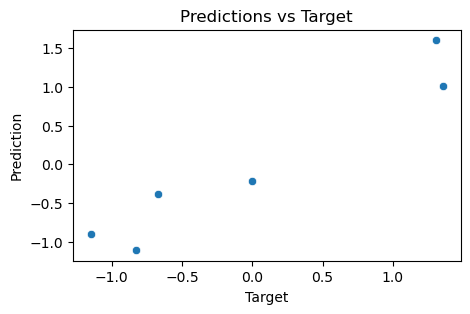

In [74]:
# Plotting predictions vs target

predictions = myModel.predict(X_test, theta)
plt.figure(figsize=(5, 3))
sns.scatterplot(x=y_test[:, 0], y=predictions[:, 0])
plt.title("Predictions vs Target")
plt.xlabel("Target")
plt.ylabel("Prediction")
plt.show()

In [75]:
X=X.reshape(-1, 1)

In [76]:
y=y.reshape(-1, 1)

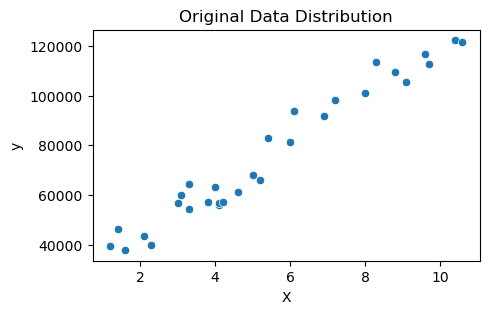

In [77]:
# Original Data Distribution 
plt.figure(figsize=(5, 3))
sns.scatterplot(x=X[:, 0], y=y[:, 0])
plt.title("Original Data Distribution")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

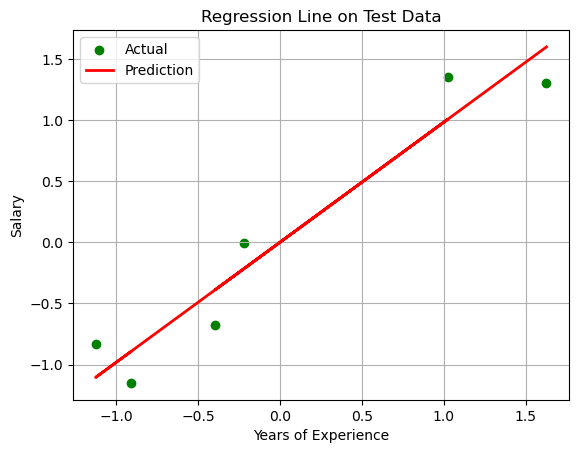

In [78]:
# Plot regression line with test data
plt.scatter(X_test, y_test, color='green', label='Actual')
plt.plot(X_test, predictions, color='red', linewidth=2, label='Prediction')
plt.title("Regression Line on Test Data")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.grid(True)
plt.show()

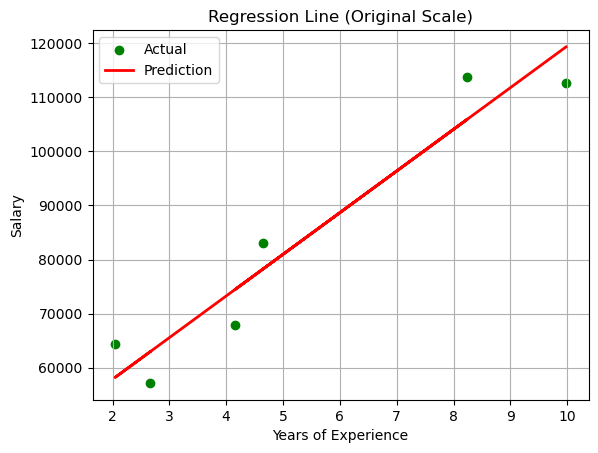

In [81]:
# Denormalize predictions and y_test
predictions_denorm = predictions * y_test_std + y_test_mean
y_test_denorm = y_test * y_test_std + y_test_mean
X_test_denorm = X_test * X_train_std + X_train_mean  # use training stats

# Plot in original scale
plt.scatter(X_test_denorm, y_test_denorm, color='green', label='Actual')
plt.plot(X_test_denorm, predictions_denorm, color='red', linewidth=2, label='Prediction')
plt.title("Regression Line (Original Scale)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.grid(True)
plt.show()


2. For the simple linear regression trained, compute all possible evaluation metrics from scratch.

In [84]:
def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def mean_absolute_percentage_error(y_true, y_pred):
    non_zero = y_true != 0
    return np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100




In [86]:
mae = mean_absolute_error(y_test, predictions)
mse = myModel.MSE_loss(predictions, y_test)  # already defined
rmse = root_mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# Inverse transform to get original scale
y_test_actual = y_test * y_test_std + y_test_mean
predictions_actual = predictions * y_test_std + y_test_mean
mape = mean_absolute_percentage_error(y_test_actual, predictions_actual)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R^2  : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")


MAE  : 0.2795
MSE  : 0.0399
RMSE : 0.2825
R^2  : 0.9202
MAPE : 8.00%




| Metric | Value | Meaning |
|--------|-------|---------|
| **MAE** (Mean Absolute Error) | 0.2795 | On average, your predictions deviate by **0.2795 units** from actual values. |
| **MSE** (Mean Squared Error) | 0.0399 | Average squared error; penalizes large errors more than MAE. Low is good. |
| **RMSE** (Root Mean Squared Error) | 0.2825 | Square root of MSE; in same unit as target. Your average error is about **0.28** units. |
| **R² (R-squared)** | 0.9202 | Your model explains **92.02%** of the variance in the salary data. Excellent score. |
| **MAPE** (Mean Absolute Percentage Error) | 8.00% | On average, your predictions are off by **8%** — **very good** (less than 10%). |

---



- Your model **fits the data well**.
- The error metrics (MAE, RMSE, MAPE) are **small**, indicating **accurate predictions**.
- The **R² score** shows that most of the variation in salary is explained by years of experience.



3. Use sklearn library to train linear regression with the same salary data and compare the evaluation metrics between two models.


In [87]:
from sklearn.linear_model import LinearRegression

# Reuse original train/test split before normalization
X = df[['YearsExperience']].values
y = df[['Salary']].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train using sklearn
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred_sklearn = lr_model.predict(X_test)


In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_sklearn = mean_absolute_error(y_test, y_pred_sklearn)
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)
r2_sklearn = r2_score(y_test, y_pred_sklearn)
mape_sklearn = np.mean(np.abs((y_test - y_pred_sklearn) / y_test)) * 100

print(f"Sklearn MAE  : {mae_sklearn:.4f}")
print(f"Sklearn MSE  : {mse_sklearn:.4f}")
print(f"Sklearn RMSE : {rmse_sklearn:.4f}")
print(f"Sklearn R²   : {r2_sklearn:.4f}")
print(f"Sklearn MAPE : {mape_sklearn:.2f}%")


Sklearn MAE  : 6286.4538
Sklearn MSE  : 49830096.8559
Sklearn RMSE : 7059.0436
Sklearn R²   : 0.9024
Sklearn MAPE : 7.74%
